<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-04-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 04
### Supervised Learning — Regression and Classification

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** |**125M1H064** |
| **Student Name** | **Manthan Vijay Sankpal**|
| **Submission Date** | **3rd of September 2026** |
</div>

---
## Assignment Objective

Implement and evaluate supervised machine learning algorithms using real-world datasets.

### Algorithms Covered
1. **Simple Linear Regression**
2. **Multiple Linear Regression**
3. **Logistic Regression**
4. **Decision Tree Classification**

### General Workflow
**Load Data → Inspect Data → Handle Missing Values → Encode/Scale Features → Train/Test Split (80:20) → Train Model → Predict → Evaluate**

In [1]:
# Libraries import

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Supervised Learning — Regression

## 1(a). California Housing Dataset

**Aim:** Predict the median house value using housing-related numerical features.

The California Housing dataset contains features such as:
- `MedInc` — median income
- `HouseAge` — median house age
- `AveRooms` — average number of rooms
- `AveBedrms` — average number of bedrooms
- `Population` — population
- `AveOccup` — average household occupancy
- `Latitude` and `Longitude`

**Target:** `MedHouseVal` — median house value.

In [2]:
# Load the California Housing dataset

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame.copy()

print("First 5 rows:")
display(housing_df.head())

print("\nDataset shape:", housing_df.shape)
print("\nColumn names:")
print(housing_df.columns.tolist())

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset shape: (20640, 9)

Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [3]:
# Data inspection and missing-value check

print("Missing values:")
display(housing_df.isnull().sum().to_frame("Missing Values"))

print("\nDataset information:")
housing_df.info()

Missing values:


,Missing Values
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Separate features and target

X = housing_df.drop("MedHouseVal", axis=1)
y = housing_df["MedHouseVal"]

# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16512
Testing samples : 4128


### Simple Linear Regression

For simple linear regression, one feature is used to predict the target.

Here, `MedInc` (median income) is selected because it is a meaningful housing-related feature.

In [5]:
# Simple Linear Regression — California Housing

X_simple = housing_df[["MedInc"]]
y = housing_df["MedHouseVal"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

simple_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

simple_lr.fit(X_train_s, y_train_s)
y_pred_s = simple_lr.predict(X_test_s)

mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("Simple Linear Regression Results")
print(f"MSE  : {mse_s:.4f}")
print(f"RMSE : {rmse_s:.4f}")
print(f"R²   : {r2_s:.4f}")

Simple Linear Regression Results
MSE  : 0.7091
RMSE : 0.8421
R²   : 0.4589


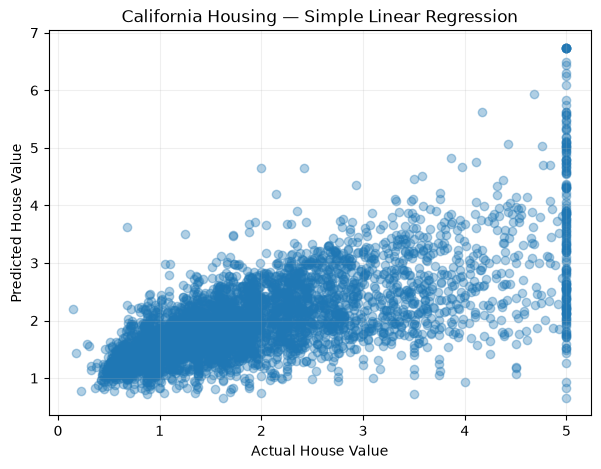

In [6]:
# Visualization — Actual vs Predicted values

plt.figure(figsize=(7, 5))
plt.scatter(y_test_s, y_pred_s, alpha=0.35)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("California Housing — Simple Linear Regression")
plt.grid(alpha=0.2)
plt.show()

### Multiple Linear Regression

Multiple linear regression uses multiple independent features to predict the target.

In [7]:
# Multiple Linear Regression — California Housing

X = housing_df.drop("MedHouseVal", axis=1)
y = housing_df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_features = X.columns.tolist()

housing_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

multiple_lr = Pipeline([
    ("preprocessor", housing_preprocessor),
    ("model", LinearRegression())
])

multiple_lr.fit(X_train, y_train)
y_pred = multiple_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Multiple Linear Regression Results
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


In [8]:
# Compare simple and multiple linear regression

comparison_housing = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MSE": [mse_s, mse],
    "RMSE": [rmse_s, rmse],
    "R2 Score": [r2_s, r2]
})

display(comparison_housing)

,Model,MSE,RMSE,R2 Score
0,Simple Linear Regression,0.709116,0.842090,0.458859
1,Multiple Linear Regression,0.555892,0.745581,0.575788


## 1(b). Automobile Dataset

**Aim:** Predict automobile price using features such as engine size, horsepower, curb weight, city MPG and highway MPG.

The Automobile dataset contains categorical and numerical attributes. For this regression task, numerical features are selected so that the focus remains on regression and numerical preprocessing.

**Target:** `price`

In [9]:
# Load Automobile dataset from the UCI Machine Learning Repository

auto_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

auto_columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg",
    "price"
]

auto_df = pd.read_csv(
    auto_url,
    names=auto_columns,
    na_values="?"
)

print("First 5 rows:")
display(auto_df.head())

print("\nDataset shape:", auto_df.shape)

First 5 rows:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0



Dataset shape: (205, 26)


In [10]:
# Automobile data inspection and missing values

print("Missing values by column:")
display(auto_df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values").head(15))

print("\nData types:")
display(auto_df.dtypes.to_frame("Data Type"))

Missing values by column:


,Missing Values
normalized-losses,41
stroke,4
price,4
bore,4
horsepower,2
peak-rpm,2
num-of-doors,2
symboling,0
fuel-type,0
make,0



Data types:


,Data Type
symboling,int64
normalized-losses,float64
make,str
fuel-type,str
aspiration,str
num-of-doors,str
body-style,str
drive-wheels,str
engine-location,str
wheel-base,float64


In [11]:
# Select useful numerical features for price prediction

auto_features = [
    "engine-size",
    "horsepower",
    "curb-weight",
    "city-mpg",
    "highway-mpg"
]

# Convert selected columns and target to numeric
for col in auto_features + ["price"]:
    auto_df[col] = pd.to_numeric(auto_df[col], errors="coerce")

auto_model_df = auto_df[auto_features + ["price"]].dropna(subset=["price"]).copy()

print("Rows available after removing records without a target price:", len(auto_model_df))
display(auto_model_df.head())

Rows available after removing records without a target price: 201


,engine-size,horsepower,curb-weight,city-mpg,highway-mpg,price
0,130,111.0,2548,21,27,13495.0
1,130,111.0,2548,21,27,16500.0
2,152,154.0,2823,19,26,16500.0
3,109,102.0,2337,24,30,13950.0
4,136,115.0,2824,18,22,17450.0


### Simple Linear Regression — Automobile

`engine-size` is used as the single predictor of automobile price.

In [12]:
# Simple Linear Regression — Automobile

X_auto_simple = auto_model_df[["engine-size"]]
y_auto = auto_model_df["price"]

X_train_as, X_test_as, y_train_as, y_test_as = train_test_split(
    X_auto_simple, y_auto, test_size=0.20, random_state=42
)

auto_simple_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

auto_simple_lr.fit(X_train_as, y_train_as)
auto_pred_s = auto_simple_lr.predict(X_test_as)

auto_mse_s = mean_squared_error(y_test_as, auto_pred_s)
auto_rmse_s = np.sqrt(auto_mse_s)
auto_r2_s = r2_score(y_test_as, auto_pred_s)

print("Automobile Simple Linear Regression")
print(f"MSE  : {auto_mse_s:.4f}")
print(f"RMSE : {auto_rmse_s:.4f}")
print(f"R²   : {auto_r2_s:.4f}")

Automobile Simple Linear Regression
MSE  : 33696986.9842
RMSE : 5804.9106
R²   : 0.7246


### Multiple Linear Regression — Automobile

Multiple numerical features are used together to predict automobile price.

In [13]:
# Multiple Linear Regression — Automobile

X_auto = auto_model_df[auto_features]
y_auto = auto_model_df["price"]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_auto, y_auto, test_size=0.20, random_state=42
)

auto_multiple_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

auto_multiple_lr.fit(X_train_a, y_train_a)
auto_pred = auto_multiple_lr.predict(X_test_a)

auto_mse = mean_squared_error(y_test_a, auto_pred)
auto_rmse = np.sqrt(auto_mse)
auto_r2 = r2_score(y_test_a, auto_pred)

print("Automobile Multiple Linear Regression")
print(f"MSE  : {auto_mse:.4f}")
print(f"RMSE : {auto_rmse:.4f}")
print(f"R²   : {auto_r2:.4f}")

Automobile Multiple Linear Regression
MSE  : 28864024.5820
RMSE : 5372.5250
R²   : 0.7641


,Model,MSE,RMSE,R2 Score
0,Simple Linear Regression,3.369699e+07,5804.910592,0.724578
1,Multiple Linear Regression,2.886402e+07,5372.524973,0.764080


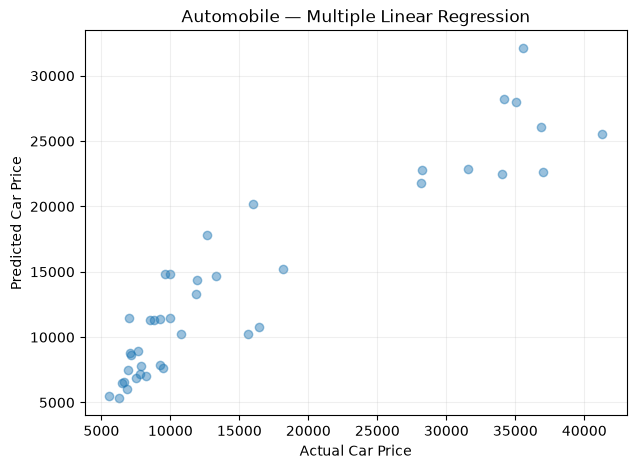

In [14]:
# Compare automobile regression models

comparison_auto = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MSE": [auto_mse_s, auto_mse],
    "RMSE": [auto_rmse_s, auto_rmse],
    "R2 Score": [auto_r2_s, auto_r2]
})

display(comparison_auto)

plt.figure(figsize=(7, 5))
plt.scatter(y_test_a, auto_pred, alpha=0.45)
plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("Automobile — Multiple Linear Regression")
plt.grid(alpha=0.2)
plt.show()

# 2. Supervised Learning — Classification

## 2(a). Pima Indians Diabetes Dataset

**Aim:** Predict whether a person has diabetes based on health-related features.

Features include:
- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

**Target:** `Outcome`  
- `0` = No diabetes
- `1` = Diabetes

A logistic regression classifier is used.

In [15]:
# Load Pima Indians Diabetes dataset

pima_urls = [
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
    "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
]

pima_columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

try:
    pima_df = pd.read_csv(pima_urls[0], names=pima_columns)
except Exception:
    pima_df = pd.read_csv(pima_urls[1])
    if "Outcome" not in pima_df.columns:
        pima_df.columns = pima_columns

print("First 5 rows:")
display(pima_df.head())

print("\nDataset shape:", pima_df.shape)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: (768, 9)


In [16]:
# Inspect and handle invalid zero values

print("Missing values before preprocessing:")
display(pima_df.isnull().sum().to_frame("Missing Values"))

# In this dataset, zero is not physiologically meaningful for several measurements.
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
pima_df[zero_as_missing] = pima_df[zero_as_missing].replace(0, np.nan)

print("\nMissing values after treating invalid zero measurements as missing:")
display(pima_df.isnull().sum().to_frame("Missing Values"))

Missing values before preprocessing:


,Missing Values
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Missing values after treating invalid zero measurements as missing:


,Missing Values
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [17]:
# Train/Test Split — Pima Diabetes

X_pima = pima_df.drop("Outcome", axis=1)
y_pima = pima_df["Outcome"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima,
    y_pima,
    test_size=0.20,
    random_state=42,
    stratify=y_pima
)

pima_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pima_model.fit(X_train_p, y_train_p)
y_pred_p = pima_model.predict(X_test_p)

print("Training samples:", len(X_train_p))
print("Testing samples :", len(X_test_p))

Training samples: 614
Testing samples : 154


In [18]:
# Evaluate Logistic Regression

pima_accuracy = accuracy_score(y_test_p, y_pred_p)
pima_precision = precision_score(y_test_p, y_pred_p)
pima_recall = recall_score(y_test_p, y_pred_p)
pima_f1 = f1_score(y_test_p, y_pred_p)

print("Pima Indians Diabetes — Logistic Regression")
print(f"Accuracy  : {pima_accuracy:.4f}")
print(f"Precision : {pima_precision:.4f}")
print(f"Recall    : {pima_recall:.4f}")
print(f"F1-score  : {pima_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_p, y_pred_p))

Pima Indians Diabetes — Logistic Regression
Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1-score  : 0.5455

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



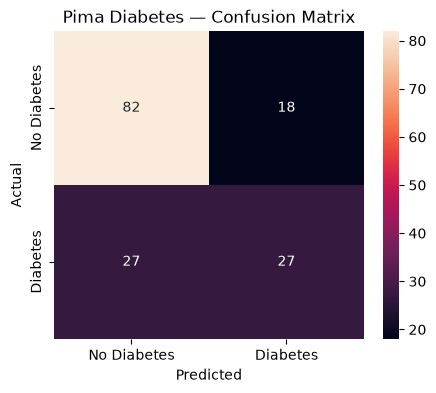

In [19]:
# Confusion Matrix — Logistic Regression

cm_pima = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_pima,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Pima Diabetes — Confusion Matrix")
plt.show()

## 2(b). Titanic Dataset

**Aim:** Predict whether a passenger survived using features such as:
- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

**Target:** `Survived`

A **Decision Tree Classifier** is used. Categorical variables are converted into numerical form using one-hot encoding.

In [20]:
# Load Titanic dataset from the given public URL

titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print("First 5 rows:")
display(titanic_df.head())

print("\nDataset shape:", titanic_df.shape)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset shape: (891, 12)


In [21]:
# Inspect missing values

print("Missing values:")
display(titanic_df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

Missing values:


,Missing Values
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [22]:
# Select features and target

titanic_features = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]

X_titanic = titanic_df[titanic_features]
y_titanic = titanic_df["Survived"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    random_state=42,
    stratify=y_titanic
)

numeric_features_t = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features_t = ["Sex", "Embarked"]

numeric_transformer_t = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_t = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

titanic_preprocessor = ColumnTransformer([
    ("num", numeric_transformer_t, numeric_features_t),
    ("cat", categorical_transformer_t, categorical_features_t)
])

print("Training samples:", len(X_train_t))
print("Testing samples :", len(X_test_t))

Training samples: 712
Testing samples : 179


In [23]:
# Decision Tree Classifier

titanic_tree = Pipeline([
    ("preprocessor", titanic_preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

titanic_tree.fit(X_train_t, y_train_t)
y_pred_t = titanic_tree.predict(X_test_t)

print("Decision Tree training completed.")

Decision Tree training completed.


In [24]:
# Evaluate Decision Tree Classifier

titanic_accuracy = accuracy_score(y_test_t, y_pred_t)
titanic_precision = precision_score(y_test_t, y_pred_t)
titanic_recall = recall_score(y_test_t, y_pred_t)
titanic_f1 = f1_score(y_test_t, y_pred_t)

print("Titanic — Decision Tree Classifier")
print(f"Accuracy  : {titanic_accuracy:.4f}")
print(f"Precision : {titanic_precision:.4f}")
print(f"Recall    : {titanic_recall:.4f}")
print(f"F1-score  : {titanic_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_t))

Titanic — Decision Tree Classifier
Accuracy  : 0.7654
Precision : 0.7547
Recall    : 0.5797
F1-score  : 0.6557

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



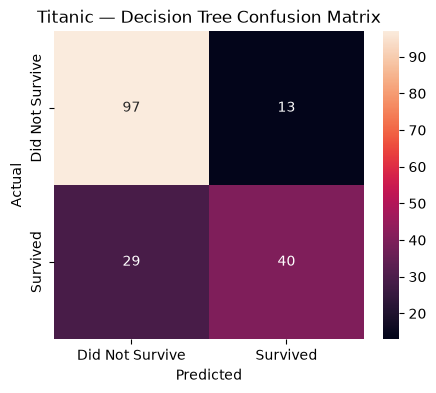

In [25]:
# Confusion Matrix — Decision Tree

cm_titanic = confusion_matrix(y_test_t, y_pred_t)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_titanic,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic — Decision Tree Confusion Matrix")
plt.show()

# Final Results Summary

The following tables summarize the performance of the regression and classification models implemented in this assignment.

In [26]:
# Final regression results

final_regression_results = pd.DataFrame([
    ["California Housing", "Simple Linear Regression", mse_s, rmse_s, r2_s],
    ["California Housing", "Multiple Linear Regression", mse, rmse, r2],
    ["Automobile", "Simple Linear Regression", auto_mse_s, auto_rmse_s, auto_r2_s],
    ["Automobile", "Multiple Linear Regression", auto_mse, auto_rmse, auto_r2]
], columns=["Dataset", "Model", "MSE", "RMSE", "R2 Score"])

display(final_regression_results)

,Dataset,Model,MSE,RMSE,R2 Score
0,California Housing,Simple Linear Regression,7.091158e-01,0.842090,0.458859
1,California Housing,Multiple Linear Regression,5.558916e-01,0.745581,0.575788
2,Automobile,Simple Linear Regression,3.369699e+07,5804.910592,0.724578
3,Automobile,Multiple Linear Regression,2.886402e+07,5372.524973,0.764080


In [27]:
# Final classification results

final_classification_results = pd.DataFrame([
    ["Pima Indians Diabetes", "Logistic Regression",
     pima_accuracy, pima_precision, pima_recall, pima_f1],
    ["Titanic", "Decision Tree",
     titanic_accuracy, titanic_precision, titanic_recall, titanic_f1]
], columns=[
    "Dataset", "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

display(final_classification_results)

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Pima Indians Diabetes,Logistic Regression,0.707792,0.600000,0.50000,0.545455
1,Titanic,Decision Tree,0.765363,0.754717,0.57971,0.655738


## Conclusion

1. Simple Linear Regression uses one independent feature, while Multiple Linear Regression uses multiple features to predict a continuous target.
2. Regression models were evaluated using MSE, RMSE and R² score.
3. Logistic Regression was used to classify diabetes outcomes into two classes.
4. A Decision Tree Classifier was used to predict Titanic passenger survival.
5. Classification models were evaluated using Accuracy, Precision, Recall and F1-score.
6. Missing numerical values were handled using median imputation, and categorical Titanic features were converted using one-hot encoding.
7. Numerical features were standardized where appropriate, especially for linear and logistic regression models.